In [7]:
# 1. Import
import numpy as np
import tensorflow as tf
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 2. Load MNIST Dataset from Keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combine train and test for full dataset
X_full = np.vstack([X_train, X_test])

# Flatten and normalize
X_full = X_full.reshape(X_full.shape[0], -1).astype('float32') / 255.0

# Use a subset for faster training (GMM is computationally expensive)
np.random.seed(42)
indices = np.random.choice(len(X_full), size=5000, replace=False)
X_original = X_full[indices]  # Keep original for visualization
y = np.concatenate([y_train, y_test])[indices]

# 3. Scale
X = StandardScaler().fit_transform(X_full[indices])

# 4. Apply PCA to reduce dimensionality (prevents singular covariance matrices)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2%}")

# 5. GMM Model with more components for digits 0-9
gmm = GaussianMixture(n_components=10, covariance_type='full', random_state=42, n_init=3, reg_covar=1e-5)
gmm.fit(X_pca)

# 6. Predict Clusters
labels = gmm.predict(X_pca)

print("Cluster Labels:", labels[:10])
print("True Labels:", y[:10])
print("GMM Convergence:", gmm.converged_)

Explained variance ratio: 60.71%
Cluster Labels: [6 0 9 8 8 4 3 9 8 0]
True Labels: [8 4 8 7 7 0 6 2 7 4]
GMM Convergence: True


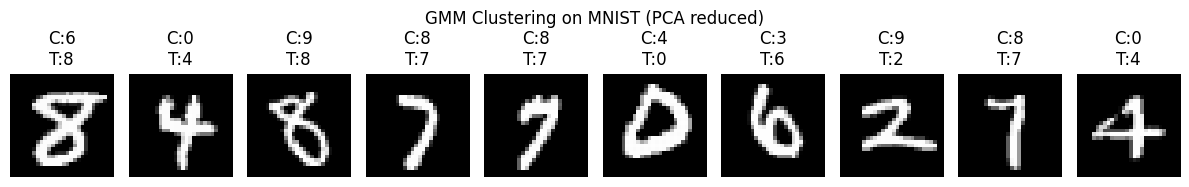


Adjusted Rand Index (ARI): 0.3112
This measures similarity between true labels and cluster assignments (1.0 = perfect)


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

# Show 10 clustered digits (use original X for visualization)
plt.figure(figsize=(12,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_original[i].reshape(28,28), cmap='gray')
    plt.title(f"C:{labels[i]}\nT:{y[i]}")
    plt.axis('off')

plt.suptitle("GMM Clustering on MNIST (PCA reduced)", fontsize=12)
plt.tight_layout()
plt.show()

# Calculate clustering accuracy
ari = adjusted_rand_score(y, labels)
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print("This measures similarity between true labels and cluster assignments (1.0 = perfect)")